In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
x = np.array([0, 5, 10, 25, 50])

In [4]:
S = np.array([
    [259, 243, 194],
    [2606, 2471, 3758],
    [5657, 4780, 5315],
    [11479, 10910, 9402],
    [18503, 18180, 18229],
    [219204, 224849, 229379],
])
S

array([[   259,    243,    194],
       [  2606,   2471,   3758],
       [  5657,   4780,   5315],
       [ 11479,  10910,   9402],
       [ 18503,  18180,  18229],
       [219204, 224849, 229379]])

In [10]:
np.array([S.mean(axis=1), S.std(axis=1)]).T

array([[2.32000000e+02, 2.76526069e+01],
       [2.94500000e+03, 5.77513636e+02],
       [5.25066667e+03, 3.60912116e+02],
       [1.05970000e+04, 8.76340497e+02],
       [1.83040000e+04, 1.42129049e+02],
       [2.24477333e+05, 4.16223164e+03]])

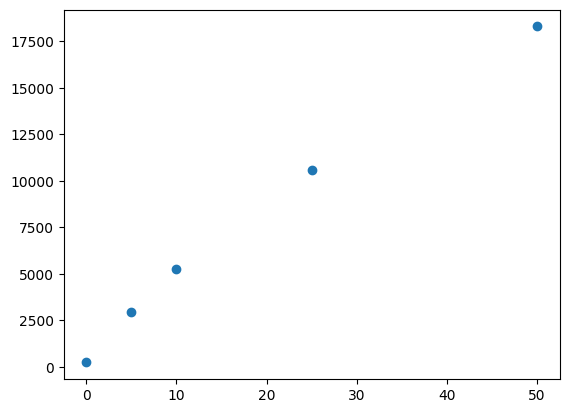

In [43]:
y = S.mean(axis=1)
std_y = S.std(axis=1)

plt.scatter(x, y[:-1])

In [39]:
A = np.vstack([x, np.ones(len(x))]).T
A

array([[ 0.,  1.],
       [ 5.,  1.],
       [10.,  1.],
       [25.,  1.],
       [50.,  1.]])

In [30]:
m, c = np.linalg.lstsq(A, y[:-1], rcond=None)[0]

In [58]:
y_nds, std_nds = S[-1].mean(), S[-1].std()
x_nds = (y_nds-c)/m
x_nds_std = (std_nds-c)/m
x_nds, x_nds_std

(632.7096103739624, 8.64246225093477)

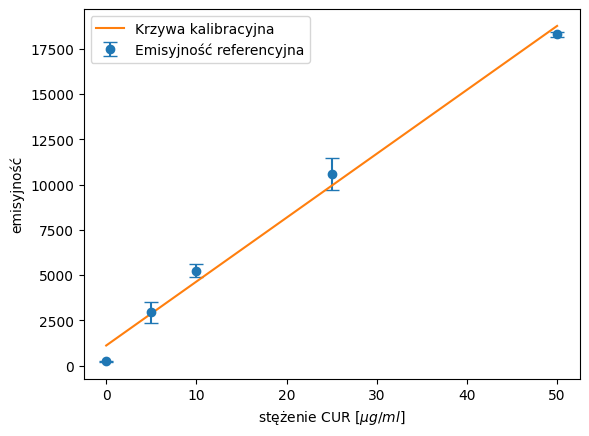

In [55]:
# plt.scatter(x, y)
x_full = np.concatenate([x,[x_nds]])
plt.errorbar(x, y[:-1], yerr=std_y[:-1], fmt='o', capsize=5, label='Emisyjność referencyjna')
plt.plot(x, m*x + c, 'tab:orange', label='Krzywa kalibracyjna')
plt.xlabel("stężenie CUR [$\mu{g}/ml$]")
plt.ylabel("emisyjność")
plt.legend()